In [4]:
#antes de empezar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Análisis de coyuntura inicial

**Proyecto TPM — Hito 2 **

En este notebook se construye el análisis de coyuntura de la economía chilena
que nos servirá de base para proyectar la Tasa de Política Monetaria.

A partir de las series almacenadas en la base de daros de aplican las transformaciones necesarias para hacerlas comparables entre sí (como variaciones interanuales, desestacionalización y series reales en vez de nominales) y se calcula la brecha de actividad a traves del filtro de Hodrick-Prescott, y se construye con el filtro de Hodrick-Prescott siguiendo la metodología de Caputo y Herrera (2013, p. 13), quienes miden la brecha de producto como la desviación de la actividad respecto de la tendencia estimada con este filtro. Se aplica sobre el Imacec (el indicador mensual de actividad disponible para Chile) con λ = 14400, el valor convencional para series de frecuencia mensual.

Con eso se construyen los gráficos que permiten seguir la evolución reciente de
la TPM y de sus principales determinantes, o sea, la inflación, la actividad, el tipo de cambio
y las expectativas. El notebook cierra con una lectura de la coyuntura, que es el
insumo del análisis económico para el informe final.

## Filtro de Hodrick-Prescott

Antes de empezar, tenemos que definir qué es el filtro de Hodrick y Prescott.
Es un filtro, valga la redundancia, que descompone una serie en dos partes: una tendencia suave, que representa el nivel potencial de la actividad, y un ciclo, que es la desviación respecto a ese potencial. Ese ciclo es la brecha de actividad (`x_t`), una de las dos variables que entran en la
regla de Taylor que el equipo estimará.

Se usa `lamb = 14400`, el valor estándar para series mensuales (1600 para
trimestrales, 100 para anuales). La función se implementa directamente con
numpy en lugar de usar `statsmodels`, por un problema que tuve de compatibilidad de
esa librería con la versión de Python que tengo en el vs, pero se supone que el resultado es idéntico.

In [5]:
import numpy as np

def filtro_hp(serie, lamb=14400):
    """Filtro de Hodrick-Prescott. Devuelve (ciclo, tendencia)."""
    y = np.asarray(serie, dtype=float)
    n = len(y)

    # Matriz de segundas diferencias: mide cuánto se "dobla" la tendencia
    K = np.zeros((n - 2, n))
    for i in range(n - 2):
        K[i, i] = 1.0
        K[i, i + 1] = -2.0
        K[i, i + 2] = 1.0

    # Resuelve el sistema (I + lambda * K'K) * tendencia = y
    tendencia = np.linalg.solve(np.eye(n) + lamb * K.T @ K, y)
    ciclo = y - tendencia

    return ciclo, tendencia

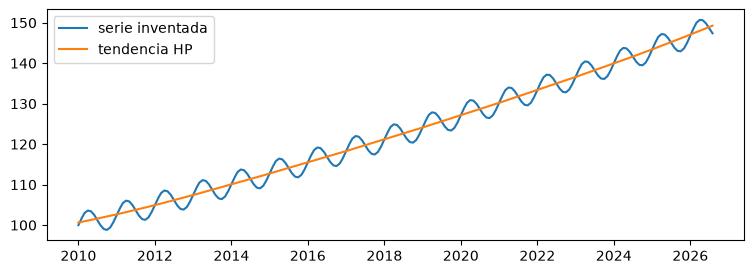

In [6]:
# CELDA TEMPORAL, hay q borrarla cuando haya una base de datos rial
fechas = pd.date_range("2010-01-01", "2026-08-01", freq="MS")
t = np.arange(len(fechas))
serie_falsa = 100 * np.exp(0.002 * t) + 3 * np.sin(2 * np.pi * t / 12)

ciclo, tendencia = filtro_hp(serie_falsa, lamb=14400)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(fechas, serie_falsa, label="serie inventada")
ax.plot(fechas, tendencia, label="tendencia HP")
ax.legend()
plt.show()

## Transformaciones

La pauta exige tres transformaciones: 

- **Variación interanual**: comparra cada mes contra el mismo mes del año anterior. Cuando comparamos meses iguales las estacionalidad se cancela y así se reporta la inflación
- **Series reales**: los salarios nominales se deflactan por el IPC, para separar   cuánto del alza es poder de compra y cuánto es solo inflación.
- **Desestacionalización**: el Imacec tiene un patrón de calendario ue hay que sacar para poder comparar un mes contra el anterior.

In [7]:
def var_interanual(serie):
    """Variación % respecto al mismo mes del año anterior."""
    return serie.pct_change(12) * 100


def serie_real(nominal, ipc):
    """Deflacta una serie nominal por el IPC."""
    return nominal / ipc * 100


def desestacionalizar(serie):
    """Quita el patrón estacional por el método de razón a media móvil."""
    s = pd.Series(serie).astype(float)

    # 1. Tendencia aproximada: promedio móvil centrado de 12 meses
    tendencia = s.rolling(12, center=True).mean()

    # 2. Cuánto se desvía cada mes de esa tendencia
    razon = s / tendencia

    # 3. Factor estacional promedio de cada mes del año, normalizado a 1
    factores = razon.groupby(s.index.month).mean()
    factores = factores / factores.mean()

    # 4. Se divide la serie original por el factor de su mes
    return s / s.index.month.map(factores)

In [8]:
# colores y estilo de los gráficos jeje
AZUL, AMBAR, VERDE = "#2f6fd0", "#d4761a", "#00968a"
GRIS, TINTA = "#9a9a97", "#2b2b29"

def estilo(ax):
    """Ejes discretos: sin marco arriba ni a la derecha, grilla tenue."""
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRIS)
    ax.grid(axis="y", color=GRIS, alpha=.25, lw=.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TINTA, labelsize=9)

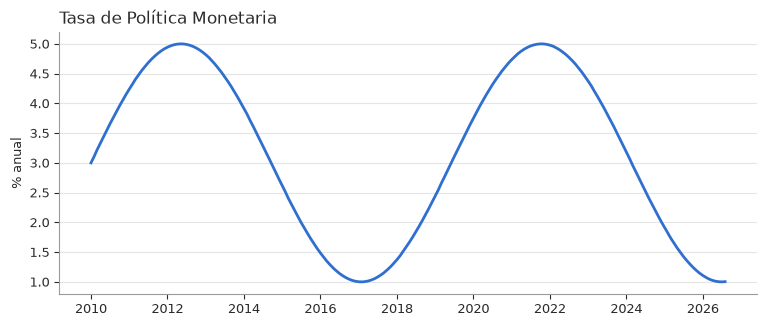

In [9]:
# CELDA TEMPORAL, son datos inventados mientras no exista la base
tpm_falsa = 3 + 2 * np.sin(np.arange(len(fechas)) / 18)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(fechas, tpm_falsa, color=AZUL, lw=2)
ax.set_title("Tasa de Política Monetaria", fontsize=12, color=TINTA, loc="left")
ax.set_ylabel("% anual", fontsize=9, color=TINTA)
estilo(ax)
plt.show()

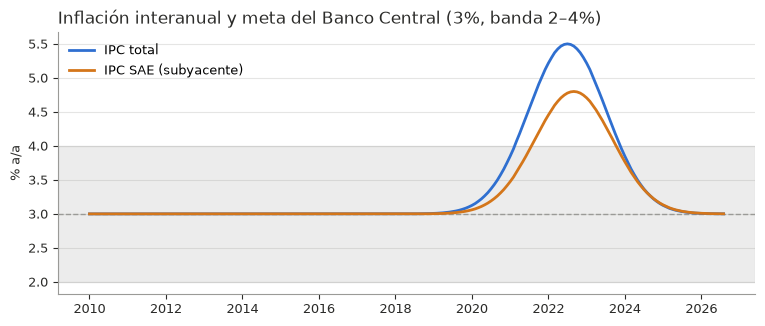

In [10]:
# CELDA TEMPORAL con atos inventados mientras no exista la base
t = np.arange(len(fechas))
inflacion_falsa = 3 + 2.5 * np.exp(-((t - 150) ** 2) / 300)
sae_falsa = 3 + 1.8 * np.exp(-((t - 152) ** 2) / 300)

fig, ax = plt.subplots(figsize=(9, 3.4))

ax.axhspan(2, 4, color=GRIS, alpha=.18)      # banda de tolerancia 2–4%
ax.axhline(3, color=GRIS, lw=1, ls="--")     # meta de 3%

ax.plot(fechas, inflacion_falsa, color=AZUL, lw=2, label="IPC total")
ax.plot(fechas, sae_falsa, color=AMBAR, lw=2, label="IPC SAE (subyacente)")

ax.set_title("Inflación interanual y meta del Banco Central (3%, banda 2–4%)",
             fontsize=12, color=TINTA, loc="left")
ax.set_ylabel("% a/a", fontsize=9, color=TINTA)
estilo(ax)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

### Actividad: Imacec, tendencia y brecha

El nivel del Imacec y la brecha van en paneles separados y no en un mismo gráfico con dos ejes verticales: al estar en unidades distintas (índice vs porcentaje), tener un doble eje permitiría sugerir cualquier relación entreambas series solo ajustando las escalas.

La brecha se grafica en barras porque es una variable con signo que oscila entorno a cero, de modo que su dirección se lee de inmediato. El filtro se aplica sobre `100 · log(Imacec)` para que el ciclo quede expresado directamente como desviación porcentual respecto de la tendencia

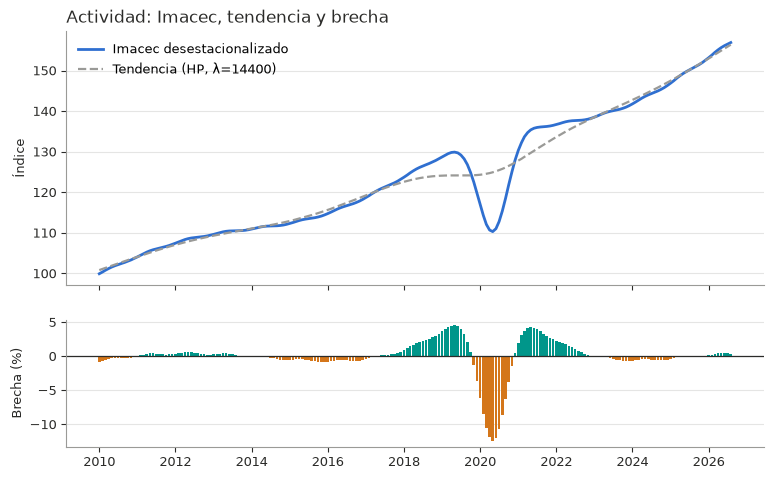

In [11]:
# CELDA TEMPORAL datos inventados mientras no exista la base
ciclo_falso = -0.18 * np.exp(-((t - 124) ** 2) / 40) + 0.02 * np.sin(t / 15)
imacec_falso = 100 * np.exp(0.0022 * t) * (1 + ciclo_falso) * (1 + 0.03 * np.sin(2 * np.pi * t / 12))
imacec_falso = pd.Series(imacec_falso, index=fechas)

# 1. Se quita la estacionalidad
imacec_sa = desestacionalizar(imacec_falso)

# 2. Se aplica el filtro HP sobre 100*log, para que la brecha quede en %
log_imacec = 100 * np.log(imacec_sa.dropna())
ciclo, tendencia = filtro_hp(log_imacec, lamb=14400)

brecha = pd.Series(ciclo, index=log_imacec.index)
tendencia_nivel = pd.Series(np.exp(tendencia / 100), index=log_imacec.index)

# 3. Dos paneles: arriba el nivel, abajo la brecha
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1], "hspace": .18})

a1.plot(imacec_sa.index, imacec_sa, color=AZUL, lw=2, label="Imacec desestacionalizado")
a1.plot(tendencia_nivel.index, tendencia_nivel, color=GRIS, lw=1.6, ls="--",
        label="Tendencia (HP, λ=14400)")
a1.set_title("Actividad: Imacec, tendencia y brecha", fontsize=12, color=TINTA, loc="left")
a1.set_ylabel("Índice", fontsize=9, color=TINTA)
estilo(a1)
a1.legend(frameon=False, fontsize=9, loc="upper left")

a2.bar(brecha.index, brecha, width=25, color=np.where(brecha >= 0, VERDE, AMBAR))
a2.axhline(0, color=TINTA, lw=.9)
a2.set_ylabel("Brecha (%)", fontsize=9, color=TINTA)
estilo(a2)

plt.show()

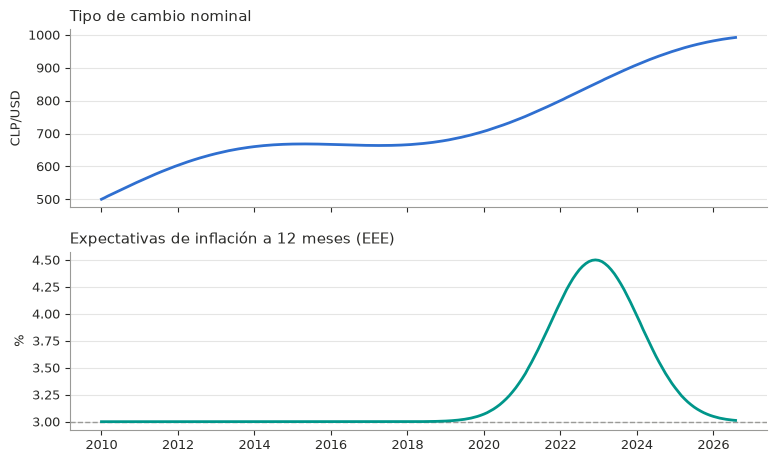

In [ ]:
# CELDA TEMPORAL datosinventados mientras no exista la base
tcn_falso = 500 + 2.2 * t + 60 * np.sin(t / 24)
eee_falsa = 3 + 1.5 * np.exp(-((t - 155) ** 2) / 400)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.2), sharex=True,
                             gridspec_kw={"hspace": .25})

a1.plot(fechas, tcn_falso, color=AZUL, lw=2)
a1.set_title("Tipo de cambio nominal", fontsize=11, color=TINTA, loc="left")
a1.set_ylabel("CLP/USD", fontsize=9, color=TINTA)
estilo(a1)

a2.axhline(3, color=GRIS, lw=1, ls="--")
a2.plot(fechas, eee_falsa, color=VERDE, lw=2)
a2.set_title("Expectativas de inflación a 12 meses (EEE)", fontsize=11, color=TINTA, loc="left")
a2.set_ylabel("%", fontsize=9, color=TINTA)
estilo(a2)

plt.show()

Van separados y no juntos por el mismo criterio que el anterior. El tipo de cambio está en pesos por dólar (números de 500 a 1000) y las expectativas en porcentaje (números del 2 al 5). Juntos en un solo gráfico con dos ejes, podrías hacer que parezca que se mueven igual o al revés, solo cambiando las escalas.